In [1]:
import os
import sys

phoci_path = os.path.abspath(os.path.join(os.getcwd(), "../PHOCI"))
if phoci_path not in sys.path:
    sys.path.append(phoci_path)

import torch 
import torch.nn as nn
import numpy as np
from torch.nn import Parameter
import torch.nn.functional as F
import torch.optim as optim
from sklearn import metrics
import os
from tqdm import tqdm


from torch_geometric.utils import to_undirected, subgraph
from torch_geometric.data import Data, Batch, DataLoader

from config import config_train, config_test

from encoder import GCNEncoder
from aggregator import MaxminMeanAggregator
from batch import load_val

import utils

In [2]:
def model_eval(data, test_batchloader, model, Aggregator):
    model.eval()
    Aggregator.eval()
    with torch.no_grad():
        total_pred = []
        test_label = []
        num_data = 0

        v = model(data.x, data.edge_index, data.edge_attr)
        
        while True :
            hedges, labels, is_last = test_batchloader.next()
            batch_size = len(hedges)
            num_data+=batch_size
            for hedge in hedges :
                embeddings = v[hedge]
                #pred, _ = Aggregator(embeddings)
                max_min_dist = torch.max(hedge) - torch.min(hedge)
                pred, _ = Aggregator(max_min_dist,embeddings)
                total_pred.append(pred.detach())
            test_label.append(labels.detach())
            
            if is_last :
                break
        total_pred = torch.stack(total_pred)       
        total_pred = total_pred.squeeze()
        test_label = torch.cat(test_label, dim=0)
        

    return total_pred.tolist(), test_label.tolist()

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [4]:
dim_edge = 400
dim_vertex = 400

alpha_e = 0
alpha_v = 0

input_dim = 15 #features_num

n_layers = 1

size = 1000
nv = size

memory_size = 0

lr = 0.00004

bs = 512

memory_size = 0
clip = 0.01
n_layers = 3


In [5]:
model_dir = '../PHOCI/models/GM12878/'

model1 = GCNEncoder(input_dim, dim_vertex, dim_vertex, n_layers)

model1.to(device)

if model_dir:
    model1.load_state_dict(torch.load(model_dir+"model"))

cls_layers = [dim_vertex*2+2, dim_vertex, 256, 128, 32, 8, 1] 
Aggregator1 = MaxminMeanAggregator(dim_vertex, cls_layers)
Aggregator1.to(device)

if model_dir:
    Aggregator1.load_state_dict(torch.load(model_dir+"Aggregator"))

In [6]:
model_dir = '../PHOCI/models/K562/'

model2 = GCNEncoder(input_dim, dim_vertex, dim_vertex, n_layers)

model2.to(device)

if model_dir:
    model2.load_state_dict(torch.load(model_dir+"model"))

cls_layers = [dim_vertex*2+2, dim_vertex, 256, 128, 32, 8, 1] 
Aggregator2 = MaxminMeanAggregator(dim_vertex, cls_layers)
Aggregator2.to(device)

if model_dir:
    Aggregator2.load_state_dict(torch.load(model_dir+"Aggregator"))

In [7]:
model_dir = '../PHOCI/models/comprehensive/'

model = GCNEncoder(input_dim, dim_vertex, dim_vertex, n_layers)

model.to(device)

if model_dir:
    model.load_state_dict(torch.load(model_dir+"model"))

cls_layers = [dim_vertex*2+2, dim_vertex, 256, 128, 32, 8, 1] #[dim_vertex, 128, 8, 1]
Aggregator = MaxminMeanAggregator(dim_vertex, cls_layers)#MaxminAggregator(dim_vertex, cls_layers)
Aggregator.to(device)

if model_dir:
    Aggregator.load_state_dict(torch.load(model_dir+"Aggregator"))

In [8]:
import pickle

In [9]:
chr_results = {}

for chr_name in ["chr13", "chr15"]: ###validation #["chr14", "chr22", "chrX"]:

    with open("../../PHOCI_processed_data/GM12878/"+chr_name+"_sliding_data","rb") as f:
        sliding_data = pickle.load(f)
        
        
    mns_aucs = []
    mns_aps = []
    sns_aucs = []
    sns_aps = []
    cns_aucs = []
    cns_aps = []
    rwcns_aucs = []
    rwcns_aps = []

    for data in sliding_data:
    
        if len(data.hyper_edge) < bs:
            continue

        data = data.to(device)
        
        test_batchloader = load_val(data.hyper_edge, bs, device, label="pos")
        val_pred_pos, total_label_pos = model_eval(data, test_batchloader, model1, Aggregator1)
                
        test_batchloader = load_val(data.mns, bs, device, label="mns")
        val_pred_mns, total_label_mns = model_eval(data, test_batchloader, model1, Aggregator1)
        mns_auc = metrics.roc_auc_score(total_label_mns+total_label_pos, val_pred_mns+val_pred_pos)
        mns_ap = metrics.average_precision_score(total_label_mns+total_label_pos, val_pred_mns+val_pred_pos)
        
        test_batchloader = load_val(data.sns, bs, device, label="sns")
        val_pred_sns, total_label_sns = model_eval(data, test_batchloader, model1, Aggregator1)
        sns_auc = metrics.roc_auc_score(total_label_sns+total_label_pos, val_pred_sns+val_pred_pos)
        sns_ap = metrics.average_precision_score(total_label_sns+total_label_pos, val_pred_sns+val_pred_pos)        
        
        test_batchloader = load_val(data.cns, bs, device, label="cns")
        val_pred_cns, total_label_cns = model_eval(data, test_batchloader, model1, Aggregator1)
        cns_auc = metrics.roc_auc_score(total_label_cns+total_label_pos, val_pred_cns+val_pred_pos)
        cns_ap = metrics.average_precision_score(total_label_cns+total_label_pos, val_pred_cns+val_pred_pos)        
    
    
        mns_aucs.append(mns_auc)
        mns_aps.append(mns_ap)
        sns_aucs.append(sns_auc)
        sns_aps.append(sns_ap)
        cns_aucs.append(cns_auc)
        cns_aps.append(cns_ap)
    
    
    chr_results[chr_name] = [mns_aucs, sns_aucs, cns_aucs, mns_aps, sns_aps, cns_aps]

    mns_aucs_val1 = np.mean(mns_aucs)
    mns_aps_val1 = np.mean(mns_aps)
    sns_aucs_val1 = np.mean(sns_aucs)
    sns_aps_val1 = np.mean(sns_aps)
    cns_aucs_val1 = np.mean(cns_aucs)
    cns_aps_val1 = np.mean(cns_aps)


    print("Chr:"+chr_name)
    print("Val mns AUC:"+str(mns_aucs_val1)+",Val mns AP:"+str(mns_aps_val1))
    print("Val sns AUC:"+str(sns_aucs_val1)+",Val sns AP:"+str(sns_aps_val1))
    print("Val cns AUC:"+str(cns_aucs_val1)+",Val cns AP:"+str(cns_aps_val1))
    

Chr:chr13
Val mns AUC:0.8913633983415205,Val mns AP:0.9002462479056541
Val sns AUC:0.9453776741482818,Val sns AP:0.9494219852580184
Val cns AUC:0.678542178088694,Val cns AP:0.7053524518673919
Chr:chr15
Val mns AUC:0.9025762364211286,Val mns AP:0.9100367316021344
Val sns AUC:0.9566435947936408,Val sns AP:0.9578195785772552
Val cns AUC:0.6965329668507285,Val cns AP:0.7224518606796536


In [10]:
chr_results = {}

for chr_name in ["chr14", "chr22", "chrX"]:

    with open("../../PHOCI_processed_data/GM12878/"+chr_name+"_sliding_data","rb") as f:
        sliding_data = pickle.load(f)
        
        
    mns_aucs = []
    mns_aps = []
    sns_aucs = []
    sns_aps = []
    cns_aucs = []
    cns_aps = []
    rwcns_aucs = []
    rwcns_aps = []

    for data in sliding_data:
    
        if len(data.hyper_edge) < bs:
            continue

        data = data.to(device)
        
        test_batchloader = load_val(data.hyper_edge, bs, device, label="pos")
        val_pred_pos, total_label_pos = model_eval(data, test_batchloader, model1, Aggregator1)
                
        test_batchloader = load_val(data.mns, bs, device, label="mns")
        val_pred_mns, total_label_mns = model_eval(data, test_batchloader, model1, Aggregator1)
        mns_auc = metrics.roc_auc_score(total_label_mns+total_label_pos, val_pred_mns+val_pred_pos)
        mns_ap = metrics.average_precision_score(total_label_mns+total_label_pos, val_pred_mns+val_pred_pos)
        
        test_batchloader = load_val(data.sns, bs, device, label="sns")
        val_pred_sns, total_label_sns = model_eval(data, test_batchloader, model1, Aggregator1)
        sns_auc = metrics.roc_auc_score(total_label_sns+total_label_pos, val_pred_sns+val_pred_pos)
        sns_ap = metrics.average_precision_score(total_label_sns+total_label_pos, val_pred_sns+val_pred_pos)        
        
        test_batchloader = load_val(data.cns, bs, device, label="cns")
        val_pred_cns, total_label_cns = model_eval(data, test_batchloader, model1, Aggregator1)
        cns_auc = metrics.roc_auc_score(total_label_cns+total_label_pos, val_pred_cns+val_pred_pos)
        cns_ap = metrics.average_precision_score(total_label_cns+total_label_pos, val_pred_cns+val_pred_pos)        
    
    
        mns_aucs.append(mns_auc)
        mns_aps.append(mns_ap)
        sns_aucs.append(sns_auc)
        sns_aps.append(sns_ap)
        cns_aucs.append(cns_auc)
        cns_aps.append(cns_ap)
    
    
    chr_results[chr_name] = [mns_aucs, sns_aucs, cns_aucs, mns_aps, sns_aps, cns_aps]

    mns_aucs_t11 = np.mean(mns_aucs)
    mns_aps_t11 = np.mean(mns_aps)
    sns_aucs_t11 = np.mean(sns_aucs)
    sns_aps_t11 = np.mean(sns_aps)
    cns_aucs_t11 = np.mean(cns_aucs)
    cns_aps_t11 = np.mean(cns_aps)


    print("Chr:"+chr_name)
    print("Test mns AUC:"+str(mns_aucs_t11)+",Test mns AP:"+str(mns_aps_t11))
    print("Test sns AUC:"+str(sns_aucs_t11)+",Test sns AP:"+str(sns_aps_t11))
    print("Test cns AUC:"+str(cns_aucs_t11)+",Test cns AP:"+str(cns_aps_t11))
    

Chr:chr14
Test mns AUC:0.9030794221129952,Test mns AP:0.9111421457049858
Test sns AUC:0.9556674812700501,Test sns AP:0.9583229677925003
Test cns AUC:0.6963015191080644,Test cns AP:0.7221283242068567
Chr:chr22
Test mns AUC:0.9054782651754272,Test mns AP:0.9138945983259367
Test sns AUC:0.9595734064561781,Test sns AP:0.962254074494995
Test cns AUC:0.6976320255129427,Test cns AP:0.7245743656697043
Chr:chrX
Test mns AUC:0.8422066549760939,Test mns AP:0.8602448928101912
Test sns AUC:0.9177015128637624,Test sns AP:0.9254146742073919
Test cns AUC:0.6446754747762937,Test cns AP:0.6759418890310325


In [11]:
chr_results = {}

for chr_name in ["chr14", "chr22", "chrX"]:

    with open("../../PHOCI_processed_data/K562/"+chr_name+"_sliding_data","rb") as f:
        sliding_data = pickle.load(f)
        
        
    mns_aucs = []
    mns_aps = []
    sns_aucs = []
    sns_aps = []
    cns_aucs = []
    cns_aps = []
    rwcns_aucs = []
    rwcns_aps = []

    for data in sliding_data:
    
        if len(data.hyper_edge) < bs:
            continue

        data = data.to(device)
        
        test_batchloader = load_val(data.hyper_edge, bs, device, label="pos")
        val_pred_pos, total_label_pos = model_eval(data, test_batchloader, model1, Aggregator1)
                
        test_batchloader = load_val(data.mns, bs, device, label="mns")
        val_pred_mns, total_label_mns = model_eval(data, test_batchloader, model1, Aggregator1)
        mns_auc = metrics.roc_auc_score(total_label_mns+total_label_pos, val_pred_mns+val_pred_pos)
        mns_ap = metrics.average_precision_score(total_label_mns+total_label_pos, val_pred_mns+val_pred_pos)
        
        test_batchloader = load_val(data.sns, bs, device, label="sns")
        val_pred_sns, total_label_sns = model_eval(data, test_batchloader, model1, Aggregator1)
        sns_auc = metrics.roc_auc_score(total_label_sns+total_label_pos, val_pred_sns+val_pred_pos)
        sns_ap = metrics.average_precision_score(total_label_sns+total_label_pos, val_pred_sns+val_pred_pos)        
        
        test_batchloader = load_val(data.cns, bs, device, label="cns")
        val_pred_cns, total_label_cns = model_eval(data, test_batchloader, model1, Aggregator1)
        cns_auc = metrics.roc_auc_score(total_label_cns+total_label_pos, val_pred_cns+val_pred_pos)
        cns_ap = metrics.average_precision_score(total_label_cns+total_label_pos, val_pred_cns+val_pred_pos)        
    
    
        mns_aucs.append(mns_auc)
        mns_aps.append(mns_ap)
        sns_aucs.append(sns_auc)
        sns_aps.append(sns_ap)
        cns_aucs.append(cns_auc)
        cns_aps.append(cns_ap)
    
    
    chr_results[chr_name] = [mns_aucs, sns_aucs, cns_aucs, mns_aps, sns_aps, cns_aps]

    mns_aucs_t12 = np.mean(mns_aucs)
    mns_aps_t12 = np.mean(mns_aps)
    sns_aucs_t12 = np.mean(sns_aucs)
    sns_aps_t12 = np.mean(sns_aps)
    cns_aucs_t12 = np.mean(cns_aucs)
    cns_aps_t12 = np.mean(cns_aps)


    print("Chr:"+chr_name)
    print("Test mns AUC:"+str(mns_aucs_t12)+",Test mns AP:"+str(mns_aps_t12))
    print("Test sns AUC:"+str(sns_aucs_t12)+",Test sns AP:"+str(sns_aps_t12))
    print("Test cns AUC:"+str(cns_aucs_t12)+",Test cns AP:"+str(cns_aps_t12))
    

Chr:chr14
Test mns AUC:0.8668781503221387,Test mns AP:0.8803333189689615
Test sns AUC:0.9348124983583158,Test sns AP:0.9411332539775562
Test cns AUC:0.6387299640026822,Test cns AP:0.6678160061631357
Chr:chr22
Test mns AUC:0.8828494576336039,Test mns AP:0.8932081631612425
Test sns AUC:0.9414681732101448,Test sns AP:0.945535485343985
Test cns AUC:0.6670241154046506,Test cns AP:0.6934875331620144
Chr:chrX
Test mns AUC:0.8177859909514691,Test mns AP:0.8366816083305084
Test sns AUC:0.8945817347046894,Test sns AP:0.9035746042916424
Test cns AUC:0.6177129387733622,Test cns AP:0.6456052914988664


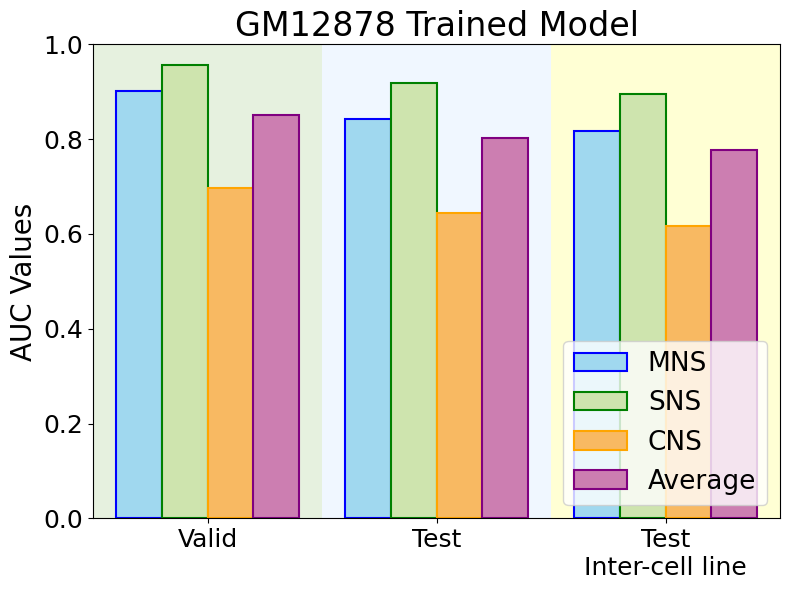

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# AUC 数据
auc_data = {
    "Valid":     [mns_aucs_val1, sns_aucs_val1, cns_aucs_val1, np.mean([mns_aucs_val1, sns_aucs_val1, cns_aucs_val1])],
    "Test\n ": [mns_aucs_t11, sns_aucs_t11, cns_aucs_t11, np.mean([mns_aucs_t11, sns_aucs_t11, cns_aucs_t11])],
    "Test\nInter-cell line": [mns_aucs_t12, sns_aucs_t12, cns_aucs_t12, np.mean([mns_aucs_t12, sns_aucs_t12, cns_aucs_t12])],
}

labels = ['MNS', 'SNS', 'CNS', 'Average']
group_names = list(auc_data.keys())

# 参数设置
n_groups = len(group_names)
n_bars_per_group = len(labels)
bar_width = 0.2
x = np.arange(n_groups)

# 颜色设置
colors = ['#a0d8ef', '#cee4ae', '#f8b962', '#cc7eb1']
edge_colors = ['blue', 'green', 'orange', 'purple']
background_colors = ['#d6e9ca', '#e6f2ff', '#ffffcc']  # 三种背景色

# 创建画布
fig, ax = plt.subplots(figsize=(8, 6))

# 绘制背景色块
for i in range(n_groups):
    ax.axvspan(i-0.5, i + 0.5, facecolor=background_colors[i], alpha=0.6)

ax.axvspan(1.5, 2.5, facecolor=background_colors[-1], alpha=0.6)    
    
# 绘制柱状图
for i in range(n_bars_per_group):
    values = [auc_data[group][i] for group in group_names]
    ax.bar(x + i * bar_width - 1.5 * bar_width, values,
           width=bar_width, label=labels[i],
           color=colors[i], edgecolor=edge_colors[i], linewidth=1.5)

# 设置标签和标题
ax.set_xticks(x)
ax.set_xticklabels(group_names, fontsize=18)
ax.set_ylabel('AUC Values', fontsize=20)
ax.set_title('GM12878 Trained Model', fontsize=24)
ax.set_ylim(0, 1.0)
ax.set_xlim(-0.5, 2.5)
ax.tick_params(axis='y', labelsize=18)
ax.legend(
    fontsize=19,
    loc='lower right',  # 图框内部右上角
    frameon=True  # 加个图例边框（可选）
)

# 美化布局
plt.tight_layout()

#plt.savefig('barplot.png', dpi=300)
plt.show()
